# 04 — Uplift Model (IPW-corrected T-Learner)
**v1** (original): plain T-Learner — biased because treated/control groups differ in risk level.  
**v2** (this notebook): T-Learner with IPW resampling — rebalances groups before fitting outcome models.

ITE = μ₀(x) − μ₁(x) where both models are fit on propensity-reweighted data.


In [1]:
import sys, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabpfn import TabPFNClassifier
from tabicl import TabICLClassifier
from feature_engineering import FEATURE_COLS
sns.set_style('whitegrid')
np.random.seed(42)


In [2]:
train = pd.read_parquet('train_features.parquet')
trim  = pd.read_parquet('trim_mask.parquet')
train = train.merge(trim, on='member_id')
df    = train[train['in_support']].copy().reset_index(drop=True)

X  = df[FEATURE_COLS].values.astype(float)
T  = df['outreach'].values
Y  = df['churn'].values
ps = df['propensity'].values

X1, Y1, ps1 = X[T==1], Y[T==1], ps[T==1]
X0, Y0, ps0 = X[T==0], Y[T==0], ps[T==0]
print(f"In-support: {len(df):,}  |  Treated: {T.sum():,}  Control: {(1-T).sum():,}")
print(f"Propensity range: [{ps.min():.3f}, {ps.max():.3f}]")


In-support: 10,000  |  Treated: 3,984  Control: 6,016
Propensity range: [0.074, 0.742]


In [3]:
def ipw_resample(X_grp, Y_grp, ps_grp, weight_fn, rng, n=None):
    """
    Resample a group with IPW weights so it looks like the full population.
    weight_fn: callable that takes ps and returns raw weights (unnormalized).
    """
    w = weight_fn(ps_grp)
    w = np.clip(w, 0, np.percentile(w, 99))  # cap extreme weights
    w = w / w.sum()
    n = n or len(X_grp)
    idx = rng.choice(len(X_grp), size=n, replace=True, p=w)
    return X_grp[idx], Y_grp[idx]


def ipw_t_learner(make_model, X, T, Y, ps, X_test, seed=42):
    """
    T-Learner with IPW resampling correction.
    Control group reweighted by ps/(1-ps)  →  looks like treated population.
    Treated group reweighted by (1-ps)/ps  →  looks like control population.
    ITE = mu0(x) - mu1(x).
    """
    eps = 1e-6
    rng = np.random.default_rng(seed)

    X1, Y1, ps1 = X[T==1], Y[T==1], ps[T==1]
    X0, Y0, ps0 = X[T==0], Y[T==0], ps[T==0]

    X0_r, Y0_r = ipw_resample(X0, Y0, ps0, lambda p: p / (1 - p + eps), rng)
    X1_r, Y1_r = ipw_resample(X1, Y1, ps1, lambda p: (1 - p) / (p + eps), rng)

    m1 = make_model(); m1.fit(X1_r, Y1_r)
    m0 = make_model(); m0.fit(X0_r, Y0_r)

    mu1 = m1.predict_proba(X_test)[:, 1]
    mu0 = m0.predict_proba(X_test)[:, 1]
    return mu0 - mu1


def make_tabpfn():
    return TabPFNClassifier(n_estimators=8, random_state=42)

def make_tabicl():
    return TabICLClassifier(random_state=42)

print("IPW T-Learner defined.")


IPW T-Learner defined.


In [4]:
# ── Sanity check: does resampling balance covariates? ────────────────────────
eps = 1e-6
rng = np.random.default_rng(42)
X0_r, Y0_r = ipw_resample(X0, Y0, ps0, lambda p: p / (1 - p + eps), rng)
X1_r, Y1_r = ipw_resample(X1, Y1, ps1, lambda p: (1 - p) / (p + eps), rng)

print("SMD before and after IPW resampling:")
print(f"{'Feature':<30} {'Raw SMD':>10} {'IPW SMD':>10}")
for i, col in enumerate(FEATURE_COLS):
    raw  = (X1[:,i].mean() - X0[:,i].mean()) / (np.sqrt((X1[:,i].std()**2 + X0[:,i].std()**2)/2) + eps)
    ipw  = (X1_r[:,i].mean() - X0_r[:,i].mean()) / (np.sqrt((X1_r[:,i].std()**2 + X0_r[:,i].std()**2)/2) + eps)
    flag = " ✓" if abs(ipw) < 0.1 else " !"
    print(f"{col:<30} {raw:>10.3f} {ipw:>10.3f}{flag}")


SMD before and after IPW resampling:
Feature                           Raw SMD    IPW SMD
tenure_days                        -0.078      0.052 ✓
total_visits                        0.023      0.021 ✓
wellco_visits                      -0.019     -0.003 ✓
health_content_ratio               -0.054      0.004 ✓
days_since_wellco                  -0.013     -0.031 ✓
unique_wellco_domains              -0.004      0.012 ✓
app_sessions                       -0.504      0.587 !
days_since_app                      0.146     -0.230 !
app_sessions_last7d                -0.376      0.427 !
icd_E11_9                          -0.009     -0.015 ✓
icd_I10                            -0.005     -0.037 ✓
icd_Z71_3                           0.021      0.059 ✓
unexpected_icd_count                0.005      0.001 ✓
expected_icd_count                  0.004      0.004 ✓


In [5]:
# ── IPW T-Learner — TabPFN ────────────────────────────────────────────────
print("Fitting IPW T-Learner (TabPFN)...")
ite_v2_tabpfn = ipw_t_learner(make_tabpfn, X, T, Y, ps, X)
print(f"ITE: mean={ite_v2_tabpfn.mean():.4f}, std={ite_v2_tabpfn.std():.4f}")
print(f"% persuadable (ITE>0): {(ite_v2_tabpfn>0).mean():.2%}")


Fitting IPW T-Learner (TabPFN)...


ITE: mean=0.0409, std=0.2993
% persuadable (ITE>0): 62.39%


In [6]:
# ── IPW T-Learner — TabICL ────────────────────────────────────────────────
print("Fitting IPW T-Learner (TabICL)...")
ite_v2_tabicl = ipw_t_learner(make_tabicl, X, T, Y, ps, X)
print(f"ITE: mean={ite_v2_tabicl.mean():.4f}, std={ite_v2_tabicl.std():.4f}")
print(f"% persuadable (ITE>0): {(ite_v2_tabicl>0).mean():.2%}")


Fitting IPW T-Learner (TabICL)...


ITE: mean=0.0424, std=0.3018
% persuadable (ITE>0): 58.97%


In [7]:
# Ensemble v2
ite_v2_ensemble = (ite_v2_tabpfn + ite_v2_tabicl) / 2
print(f"Ensemble v2: mean={ite_v2_ensemble.mean():.4f}, std={ite_v2_ensemble.std():.4f}")
print(f"% persuadable: {(ite_v2_ensemble>0).mean():.2%}")

df['ite_v2_tabpfn']  = ite_v2_tabpfn
df['ite_v2_tabicl']  = ite_v2_tabicl
df['ite_v2_ensemble']= ite_v2_ensemble


Ensemble v2: mean=0.0417, std=0.3001
% persuadable: 61.22%


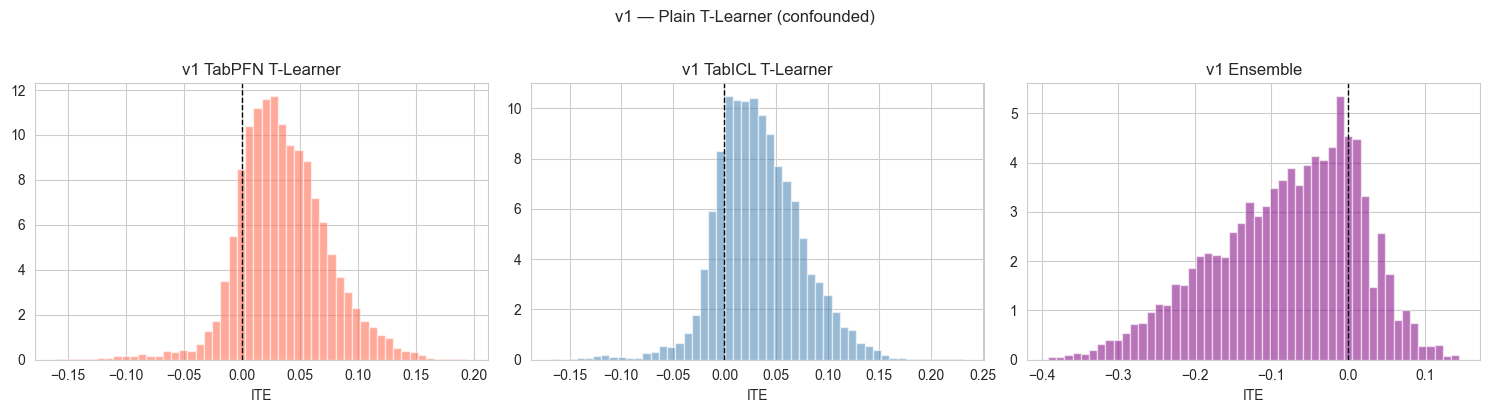

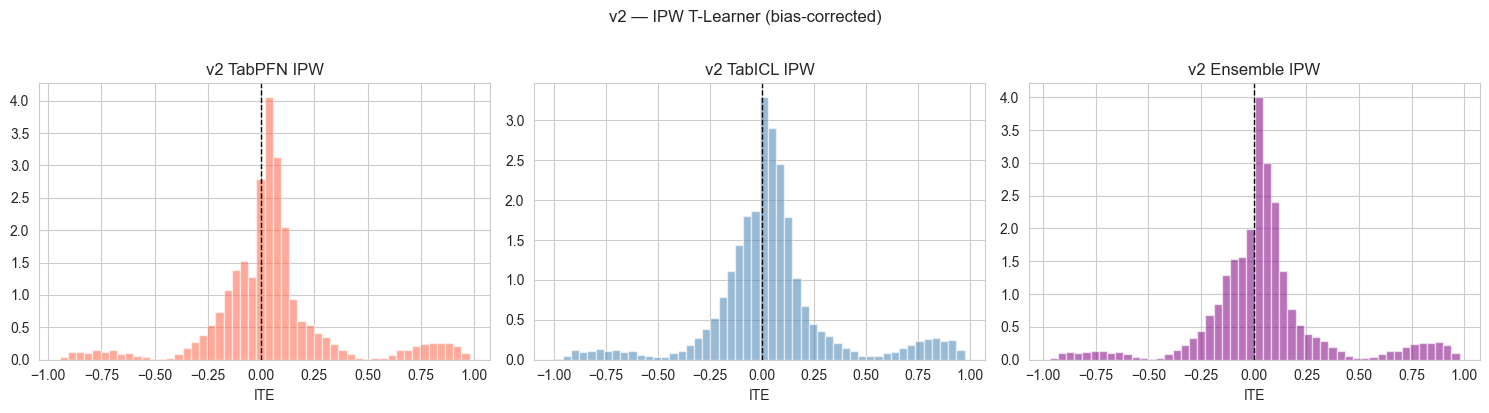

In [8]:
# Compare v1 (plain T-Learner) vs v2 (IPW) ITE distributions
# Load v1 from saved parquet
v1 = pd.read_parquet('test_predictions.parquet')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models = [('ite_tpfn_t','v1 TabPFN T-Learner','tomato'),
          ('ite_ticl_t','v1 TabICL T-Learner','steelblue'),
          ('ite_ensemble','v1 Ensemble','purple')]
for ax, (col, title, color) in zip(axes, models):
    ax.hist(v1[col], bins=50, alpha=0.55, label=title, color=color, density=True)
    ax.axvline(0, color='black', lw=1, ls='--')
    ax.set_title(title); ax.set_xlabel('ITE')
plt.suptitle('v1 — Plain T-Learner (confounded)', y=1.02)
plt.tight_layout()
plt.savefig('ite_v1_dist.png', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (vals, title, color) in zip(axes, [
    (ite_v2_tabpfn, 'v2 TabPFN IPW','tomato'),
    (ite_v2_tabicl, 'v2 TabICL IPW','steelblue'),
    (ite_v2_ensemble,'v2 Ensemble IPW','purple')]):
    ax.hist(vals, bins=50, alpha=0.55, label=title, color=color, density=True)
    ax.axvline(0, color='black', lw=1, ls='--')
    ax.set_title(title); ax.set_xlabel('ITE')
plt.suptitle('v2 — IPW T-Learner (bias-corrected)', y=1.02)
plt.tight_layout()
plt.savefig('ite_v2_dist.png', bbox_inches='tight')
plt.show()


In [9]:
# ── Predict on TEST set — refit on full in-support train ─────────────────
test = pd.read_parquet('test_features.parquet')
X_test = test[FEATURE_COLS].values.astype(float)

print("Predicting on test set (IPW T-Learner, TabPFN)...")
ite_test_v2_tabpfn = ipw_t_learner(make_tabpfn, X, T, Y, ps, X_test)

print("Predicting on test set (IPW T-Learner, TabICL)...")
ite_test_v2_tabicl = ipw_t_learner(make_tabicl, X, T, Y, ps, X_test)

ite_test_v2_ensemble = (ite_test_v2_tabpfn + ite_test_v2_tabicl) / 2

test['ite_v2_tabpfn']   = ite_test_v2_tabpfn
test['ite_v2_tabicl']   = ite_test_v2_tabicl
test['ite_v2_ensemble'] = ite_test_v2_ensemble

print(f"\nTest ITE v2 TabPFN:   mean={ite_test_v2_tabpfn.mean():.4f}, % pos: {(ite_test_v2_tabpfn>0).mean():.2%}")
print(f"Test ITE v2 TabICL:   mean={ite_test_v2_tabicl.mean():.4f}, % pos: {(ite_test_v2_tabicl>0).mean():.2%}")
print(f"Test ITE v2 Ensemble: mean={ite_test_v2_ensemble.mean():.4f}, % pos: {(ite_test_v2_ensemble>0).mean():.2%}")


Predicting on test set (IPW T-Learner, TabPFN)...


Predicting on test set (IPW T-Learner, TabICL)...



Test ITE v2 TabPFN:   mean=0.0380, % pos: 83.46%
Test ITE v2 TabICL:   mean=0.0399, % pos: 75.07%
Test ITE v2 Ensemble: mean=0.0390, % pos: 80.31%


In [10]:
# Save
test.to_parquet('test_predictions_v2.parquet', index=False)
print("Saved test_predictions_v2.parquet")

# Write v2 prediction CSVs
for col, suffix in [('ite_v2_tabpfn','tabpfn'),('ite_v2_tabicl','tabicl'),('ite_v2_ensemble','ensemble')]:
    s = test.sort_values(col, ascending=False).reset_index(drop=True)
    sel = s[s[col] > 0].copy()
    sel['rank'] = range(1, len(sel)+1)
    out = sel[['member_id', col, 'rank']].rename(columns={col:'ite_score'})
    fname = f'predictions_v2_{suffix}.csv'
    out.to_csv(fname, index=False)
    print(f"{fname}: {len(out):,} members, ITE range [{out['ite_score'].min():.4f}, {out['ite_score'].max():.4f}]")


Saved test_predictions_v2.parquet
predictions_v2_tabpfn.csv: 8,346 members, ITE range [0.0000, 0.2770]
predictions_v2_tabicl.csv: 7,507 members, ITE range [0.0000, 0.5979]
predictions_v2_ensemble.csv: 8,031 members, ITE range [0.0000, 0.3326]
